In [2]:
# =============================================================================
# OmniFold unfolding of J/psi pT^2 in ultra-peripheral Pb-Pb collisions
# Process: coherent J/psi -> mu+ mu- at midrapidity
# MC production: LHC25g15 (STARlight + GEANT4 via O2)
#
# Pipeline:
#   1. Load the MC TTree and validate branches
#   2. Compute J/psi invariant mass (sanity) and pT^2 (observable) once
#   3. Apply fiducial pT^2 cut, then split 80% MC / 20% pseudodata
#   4. Plot migration (purity + efficiency) BEFORE unfolding
#   5. Run OmniFold (MultiFold) with two MLP classifiers
#   6. Plot migration AFTER unfolding and closure test vs pseudodata truth
# =============================================================================

import numpy as np
import uproot
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

import omnifold as of
from omnifold import MultiFold

In [3]:
# =============================================================================
# Analysis constants — single source of truth
# =============================================================================
ROOT_FILE = "TTTT.LHC25g15.kCohJpsiToMu.HY639424.root"
TREE_PATH = "DF_2338652700415296/O2truetwotrack"

M_MU     = 0.105658            # muon mass [GeV/c^2]
PT2_CUT  = 0.11 ** 2           # fiducial pT^2 cut [GeV^2/c^2] -> 0.0121
BINS     = [0, 0.001, 0.002, 0.004, 0.006, 0.008, 0.012]
RNG_SEED = 42                  # for the train/test split

In [4]:
# =============================================================================
# Load the MC ROOT file produced by the O2 analysis task.
# TTree "O2truetwotrack" contains matched (gen, reco) pairs for
# coherent J/psi -> mu+ mu- events. Each entry has exactly 2 daughters.
# =============================================================================
rootfile = uproot.open(ROOT_FILE)
tree     = rootfile[TREE_PATH]
data     = tree.arrays(library="np")

print(f"Entries: {tree.num_entries}")
print(f"Branches: {list(data.keys())}")

Entries: 6698050
Branches: ['fRunNumber', 'fBc', 'fTotalTracks', 'fNumContrib', 'fGlobalNonPVtracks', 'fPosX', 'fPosY', 'fPosZ', 'fRecoMode', 'fOccupancyInTime', 'fHadronicRate', 'fTrs', 'fTrofs', 'fHmpr', 'fTfb', 'fItsRofb', 'fSbp', 'fZvtxFT0vsPv', 'fVtxITSTPC', 'fTotalFT0AmplitudeA', 'fTotalFT0AmplitudeC', 'fTotalFV0AmplitudeA', 'fEnergyCommonZNA', 'fEnergyCommonZNC', 'fTimeFT0A', 'fTimeFT0C', 'fTimeFV0A', 'fTimeZNA', 'fTimeZNC', 'fTrkPx', 'fTrkPy', 'fTrkPz', 'fTrkSign', 'fTrkDCAxy', 'fTrkDCAz', 'fTrkTimeRes', 'fTrk1ITSclusterSizes', 'fTrk2ITSclusterSizes', 'fTrkTPCsignal', 'fTrkTPCnSigmaEl', 'fTrkTPCnSigmaMu', 'fTrkTPCnSigmaPi', 'fTrkTPCnSigmaKa', 'fTrkTPCnSigmaPr', 'fTrkTPCinnerParam', 'fTrkTOFsignal', 'fTrkTOFnSigmaEl', 'fTrkTOFnSigmaMu', 'fTrkTOFnSigmaPi', 'fTrkTOFnSigmaKa', 'fTrkTOFnSigmaPr', 'fTrkTOFexpMom', 'fTrueChannel', 'fTrueHasRecoColl', 'fTruePosX', 'fTruePosY', 'fTruePosZ', 'fTrueMotherPx', 'fTrueMotherPy', 'fTrueMotherPz', 'fTrueDaugPx', 'fTrueDaugPy', 'fTrueDaugPz', '

In [5]:
# =============================================================================
# Validate that every track-like branch (Trk, Daug, Mother) has exactly
# 2 elements per entry — one per muon daughter. Guards against variable-
# length arrays that would break the fixed-index slicing ([:, 0], [:, 1]).
# =============================================================================
track_branches = [k for k in data if any(t in k for t in ("Trk", "Daug", "Mother"))]
print(f"Track-like branches: {track_branches}")

for branch in track_branches:
    arr = data[branch]
    if hasattr(arr[0], "__len__"):
        bad = [i for i, e in enumerate(arr) if len(e) != 2]
        if bad:
            print(f"  {branch}: {len(bad)} entries do NOT have 2 elements (first 5: {bad[:5]})")
        else:
            print(f"  {branch}: OK — all {len(arr)} entries have exactly 2 elements")
    else:
        print(f"  {branch}: scalar (not an array per entry)")

Track-like branches: ['fTrkPx', 'fTrkPy', 'fTrkPz', 'fTrkSign', 'fTrkDCAxy', 'fTrkDCAz', 'fTrkTimeRes', 'fTrk1ITSclusterSizes', 'fTrk2ITSclusterSizes', 'fTrkTPCsignal', 'fTrkTPCnSigmaEl', 'fTrkTPCnSigmaMu', 'fTrkTPCnSigmaPi', 'fTrkTPCnSigmaKa', 'fTrkTPCnSigmaPr', 'fTrkTPCinnerParam', 'fTrkTOFsignal', 'fTrkTOFnSigmaEl', 'fTrkTOFnSigmaMu', 'fTrkTOFnSigmaPi', 'fTrkTOFnSigmaKa', 'fTrkTOFnSigmaPr', 'fTrkTOFexpMom', 'fTrueMotherPx', 'fTrueMotherPy', 'fTrueMotherPz', 'fTrueDaugPx', 'fTrueDaugPy', 'fTrueDaugPz', 'fTrueDaugPdgCode']
  fTrkPx: OK — all 6698050 entries have exactly 2 elements
  fTrkPy: OK — all 6698050 entries have exactly 2 elements
  fTrkPz: OK — all 6698050 entries have exactly 2 elements
  fTrkSign: OK — all 6698050 entries have exactly 2 elements
  fTrkDCAxy: OK — all 6698050 entries have exactly 2 elements
  fTrkDCAz: OK — all 6698050 entries have exactly 2 elements
  fTrkTimeRes: OK — all 6698050 entries have exactly 2 elements
  fTrk1ITSclusterSizes: scalar (not an array 

In [6]:
# =============================================================================
# Helper functions — defined once, reused throughout the notebook.
#
#   invariant_mass(px, py, pz, m)  : (N,2) 4-momenta -> (N,) inv mass
#   pt2_sum(px, py)                : (N,2) -> (N,) squared vector sum pT
#   compute_migration(reco, gen, bins, weights=None) -> (purity%, eff%)
#   plot_matrix(mat, bins, title, xlabel, ylabel)
#   plot_mass(m, bins, rng, color, title, log=False)
# =============================================================================

def invariant_mass(px, py, pz, m):
    """Invariant mass of a pair of particles with common mass `m`."""
    e = np.sqrt(px**2 + py**2 + pz**2 + m**2)
    s = (e.sum(axis=1)**2
         - px.sum(axis=1)**2 - py.sum(axis=1)**2 - pz.sum(axis=1)**2)
    return np.sqrt(np.clip(s, 0.0, None))

def pt2_sum(px, py):
    """Squared pT of the vector sum of a pair."""
    return px.sum(axis=1)**2 + py.sum(axis=1)**2

def compute_migration(pt2_reco_arr, pt2_gen_arr, bins, weights=None):
    """Return (purity%, efficiency%) migration matrices for a (reco, gen) pair."""
    n_bins = len(bins) - 1
    mig = np.zeros((n_bins, n_bins))
    idx_r = np.digitize(pt2_reco_arr, bins) - 1
    idx_g = np.digitize(pt2_gen_arr,  bins) - 1
    if weights is None:
        weights = np.ones(len(pt2_reco_arr))
    for r, g, w in zip(idx_r, idx_g, weights):
        if 0 <= r < n_bins and 0 <= g < n_bins:
            mig[r, g] += w

    purity = np.zeros_like(mig)
    for r in range(n_bins):
        s = mig[r, :].sum()
        if s > 0:
            purity[r, :] = mig[r, :] / s * 100

    efficiency = np.zeros_like(mig)
    for g in range(n_bins):
        s = mig[:, g].sum()
        if s > 0:
            efficiency[:, g] = mig[:, g] / s * 100

    return purity, efficiency

def plot_matrix(matrix, bins, title, xlabel, ylabel):
    """Plot a normalized (%) migration matrix as an annotated heatmap."""
    n_bins = len(bins) - 1
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(matrix.T, origin="lower", aspect="auto",
                   extent=[0, n_bins, 0, n_bins], cmap="Blues", vmin=0, vmax=100)
    plt.colorbar(im, ax=ax, label="%")
    for r in range(n_bins):
        for g in range(n_bins):
            val = matrix[r, g]
            ax.text(r + 0.5, g + 0.5, f"{val:.1f}%",
                    ha="center", va="center", fontsize=9,
                    color="white" if val > 50 else "black")
    labels = [f"{bins[i]*1000:.1f}-{bins[i+1]*1000:.1f}" for i in range(n_bins)]
    ax.set_xticks(np.arange(n_bins) + 0.5); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(np.arange(n_bins) + 0.5); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    plt.tight_layout(); plt.show()

def plot_mass(m, bins, rng, color, title, log=False):
    """Stand-alone invariant mass sanity plot."""
    plt.figure()
    plt.hist(m, bins=bins, range=rng, histtype="step", color=color)
    plt.xlabel(r"$M_{\mu\mu}$ [GeV]"); plt.ylabel("Entries")
    if log:
        plt.yscale("log")
    plt.title(title)
    plt.show()

In [7]:
# =============================================================================
# Compute gen- and reco-level J/psi invariant mass and pT^2 for the full
# sample, once. Fully vectorized — no Python-level event loops.
#
#   pT^2 = (px1 + px2)^2 + (py1 + py2)^2  (sum over the two muon daughters)
# For coherent J/psi photoproduction, pT^2 encodes the nuclear form factor
# and is the observable to be unfolded.
# =============================================================================
inv_mass_gen  = invariant_mass(data["fTrueDaugPx"], data["fTrueDaugPy"],
                               data["fTrueDaugPz"], M_MU)
inv_mass_reco = invariant_mass(data["fTrkPx"],      data["fTrkPy"],
                               data["fTrkPz"],      M_MU)

pt2_gen  = pt2_sum(data["fTrueDaugPx"], data["fTrueDaugPy"])
pt2_reco = pt2_sum(data["fTrkPx"],      data["fTrkPy"])

print(f"Computed inv-mass and pT^2 for {len(pt2_gen)} events.")

Computed inv-mass and pT^2 for 6698050 events.


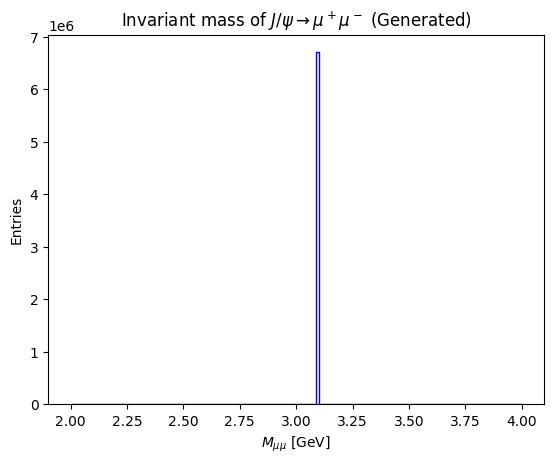

In [8]:
# Sanity: generated invariant mass should peak at M(J/psi) ~ 3.097 GeV.
plot_mass(inv_mass_gen, bins=200, rng=(2.0, 4.0), color="blue",
          title=r"Invariant mass of $J/\psi \to \mu^+\mu^-$ (Generated)")

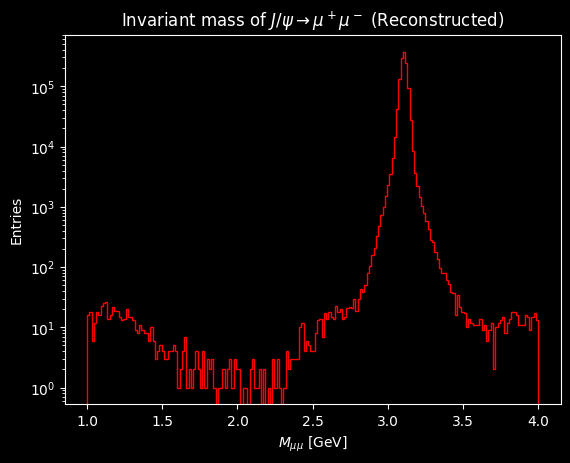

In [8]:
# Sanity: reconstructed invariant mass, smeared by detector resolution.
plot_mass(inv_mass_reco, bins=200, rng=(1.0, 4.0), color="red",
          title=r"Invariant mass of $J/\psi \to \mu^+\mu^-$ (Reconstructed)",
          log=True)

In [9]:
# =============================================================================
# Apply fiducial pT^2 cut to BOTH gen and reco, then split 80% MC / 20% pseudodata.
# The split is done on *indices* into the (cut) full-sample arrays, so MC and
# pseudodata are disjoint and the pseudodata truth is held back for closure only.
# =============================================================================
fid          = (pt2_gen < PT2_CUT) & (pt2_reco < PT2_CUT)
fid_indices  = np.where(fid)[0]

idx_mc, idx_test = train_test_split(fid_indices, test_size=0.2, random_state=RNG_SEED)

mc_pt2_gen,   mc_pt2_reco   = pt2_gen[idx_mc],   pt2_reco[idx_mc]
test_pt2_gen, test_pt2_reco = pt2_gen[idx_test], pt2_reco[idx_test]

print(f"MC (training)    events after fiducial cut: {len(mc_pt2_gen)}")
print(f"Pseudodata (test) events after fiducial cut: {len(test_pt2_gen)}")

MC (training)    events after fiducial cut: 936454
Pseudodata (test) events after fiducial cut: 234114


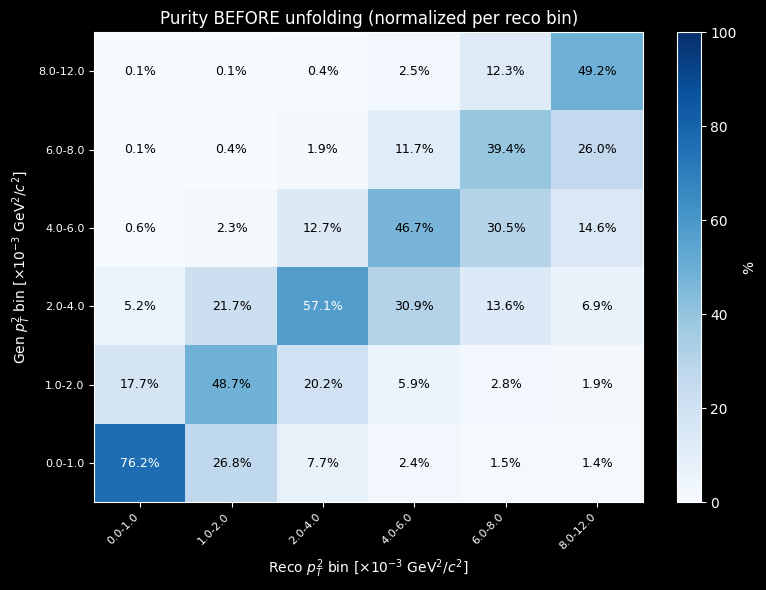

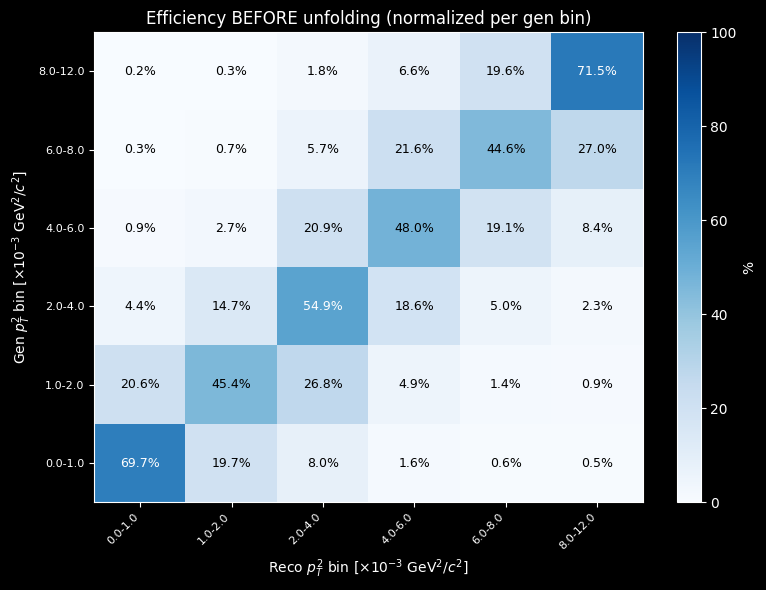

Diagonal purity per reco bin:
  0.0-1.0: 76.2%
  1.0-2.0: 48.7%
  2.0-4.0: 57.1%
  4.0-6.0: 46.7%
  6.0-8.0: 39.4%
  8.0-12.0: 49.2%
Diagonal efficiency per gen bin:
  0.0-1.0: 69.7%
  1.0-2.0: 45.4%
  2.0-4.0: 54.9%
  4.0-6.0: 48.0%
  6.0-8.0: 44.6%
  8.0-12.0: 71.5%


In [10]:
# =============================================================================
# Purity and efficiency BEFORE unfolding (unweighted MC training sample).
# Baseline: how well the detector maps gen -> reco without correction.
#   High diagonal purity     = reco bins are already clean
#   High diagonal efficiency = gen events mostly stay in their bin after reco
# =============================================================================
purity_before, eff_before = compute_migration(mc_pt2_reco, mc_pt2_gen, BINS)

plot_matrix(purity_before, BINS,
    "Purity BEFORE unfolding (normalized per reco bin)",
    r"Reco $p_T^2$ bin [$\times 10^{-3}$ GeV$^2/c^2$]",
    r"Gen $p_T^2$ bin [$\times 10^{-3}$ GeV$^2/c^2$]")

plot_matrix(eff_before, BINS,
    "Efficiency BEFORE unfolding (normalized per gen bin)",
    r"Reco $p_T^2$ bin [$\times 10^{-3}$ GeV$^2/c^2$]",
    r"Gen $p_T^2$ bin [$\times 10^{-3}$ GeV$^2/c^2$]")

print("Diagonal purity per reco bin:")
for r in range(len(BINS) - 1):
    print(f"  {BINS[r]*1000:.1f}-{BINS[r+1]*1000:.1f}: {purity_before[r, r]:.1f}%")
print("Diagonal efficiency per gen bin:")
for g in range(len(BINS) - 1):
    print(f"  {BINS[g]*1000:.1f}-{BINS[g+1]*1000:.1f}: {eff_before[g, g]:.1f}%")

In [11]:
# =============================================================================
# Build the OmniFold DataLoaders and two MLP classifiers.
#
#   pseudo_data : measured reco-level "data" (gen withheld)
#   training_mc : paired (gen, reco) simulation
#   model1      : step-1 classifier, reco-level (data vs MC reco)
#   model2      : step-2 classifier, gen-level  (MC gen vs reweighted MC gen)
# =============================================================================
pseudo_data = of.DataLoader(reco=test_pt2_reco, normalize=True)
training_mc = of.DataLoader(reco=mc_pt2_reco, gen=mc_pt2_gen, normalize=True)

model1 = of.MLP(1)
model2 = of.MLP(1)

INFO: Creating weights ...
INFO: Creating pass reco flag ...
INFO: Normalizing sum of weights to 1000000 ...
INFO: Creating weights ...
INFO: Creating pass reco flag ...
INFO: Creating pass gen flag ...
INFO: Normalizing sum of weights to 1000000 ...


In [12]:
# =============================================================================
# Run OmniFold (MultiFold). Each iteration does two steps:
#   Step 1 (pull): reweight MC reco -> data reco via model1
#   Step 2 (push): reweight MC gen  -> reweighted MC gen via model2
# After niter iterations the push weights applied to MC gen approximate the
# true gen-level distribution that produced the observed (pseudo)data.
# =============================================================================
omnifold_object = MultiFold(
    "JpsiPt2Mid",
    model1,
    model2,
    pseudo_data,
    training_mc,
    batch_size     = 512,
    niter          = 5,
    epochs         = 10,
    weights_folder = "weights",
    verbose        = True,
    lr             = 5e-5,
)
omnifold_object.Unfold()

2286 training steps at reco and 3658 steps at gen
ITERATION: 1
RUNNING STEP 1
Creating cached data from step 1
################################################################################
Train events used: 1170432, Test events used: 234086
################################################################################
Epoch 1/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1.1845 - val_loss: 1.1835 - learning_rate: 5.0000e-05
Epoch 2/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.1846 - val_loss: 1.1835 - learning_rate: 5.0000e-05
Epoch 3/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.1845 - val_loss: 1.1835 - learning_rate: 5.0000e-05
Epoch 4/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.1845 - val_loss: 1.1835 - learning_rate: 5.0000e-05
Epoch 5/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.1844 - val_loss: 1.1835 - learning_rate: 5.0000e-05
Epoch 6/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.1847 - val_loss: 1.1835 - lear

In [13]:
# Final push weights, one per MC gen event. Applying these to `mc_pt2_gen`
# gives the unfolded distribution. (Equivalent to
# omnifold_object.reweight(training_mc.gen, omnifold_object.model2, batch_size=1000).)
w_unfolded = omnifold_object.weights_push

assert w_unfolded.shape == mc_pt2_gen.shape, (
    f"weights ({w_unfolded.shape}) vs mc_pt2_gen ({mc_pt2_gen.shape}) mismatch"
)
print(f"Unfolded weights: shape={w_unfolded.shape}, sum={w_unfolded.sum():.1f}")

Unfolded weights: shape=(936454,), sum=936473.1


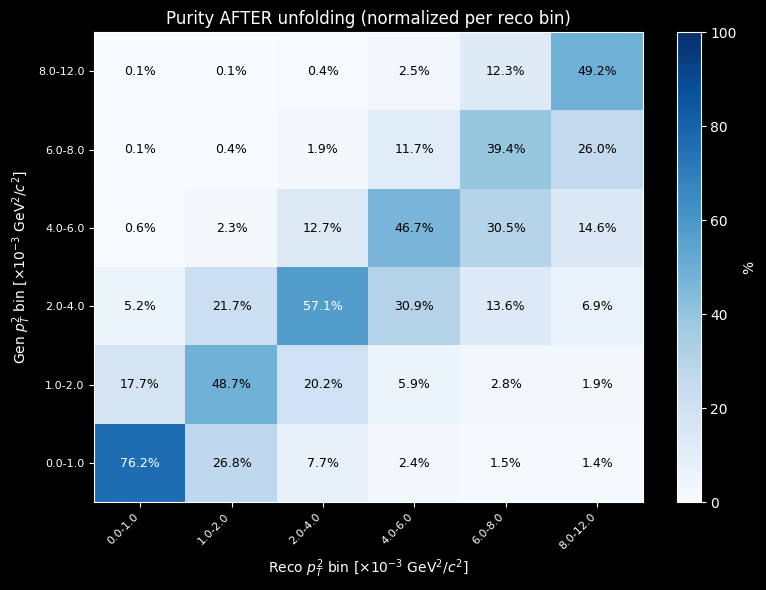

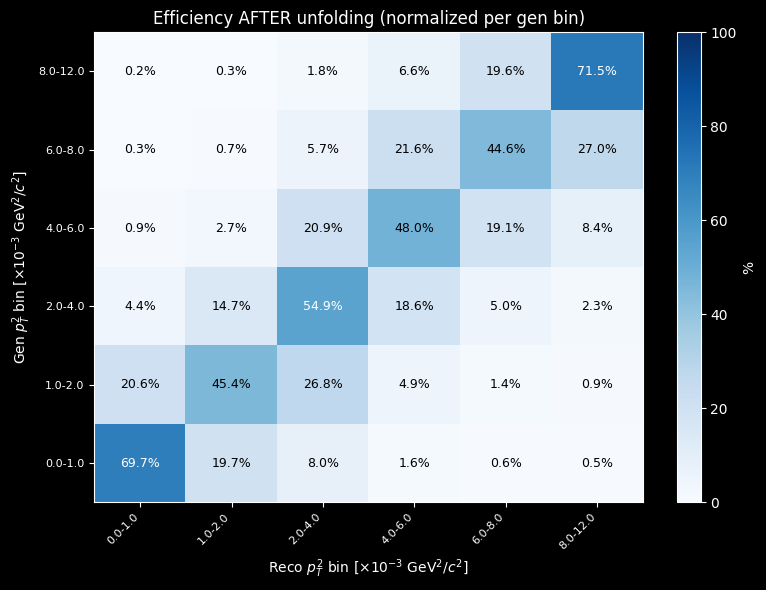

In [14]:
# =============================================================================
# Purity and efficiency AFTER unfolding. MC training events are weighted by
# the final OmniFold push weights. If unfolding worked the diagonal should
# be more dominant (sharper gen-reco correspondence in the weighted sample).
# =============================================================================
purity_after, eff_after = compute_migration(mc_pt2_reco, mc_pt2_gen, BINS,
                                            weights=w_unfolded)

plot_matrix(purity_after, BINS,
    "Purity AFTER unfolding (normalized per reco bin)",
    r"Reco $p_T^2$ bin [$\times 10^{-3}$ GeV$^2/c^2$]",
    r"Gen $p_T^2$ bin [$\times 10^{-3}$ GeV$^2/c^2$]")

plot_matrix(eff_after, BINS,
    "Efficiency AFTER unfolding (normalized per gen bin)",
    r"Reco $p_T^2$ bin [$\times 10^{-3}$ GeV$^2/c^2$]",
    r"Gen $p_T^2$ bin [$\times 10^{-3}$ GeV$^2/c^2$]")

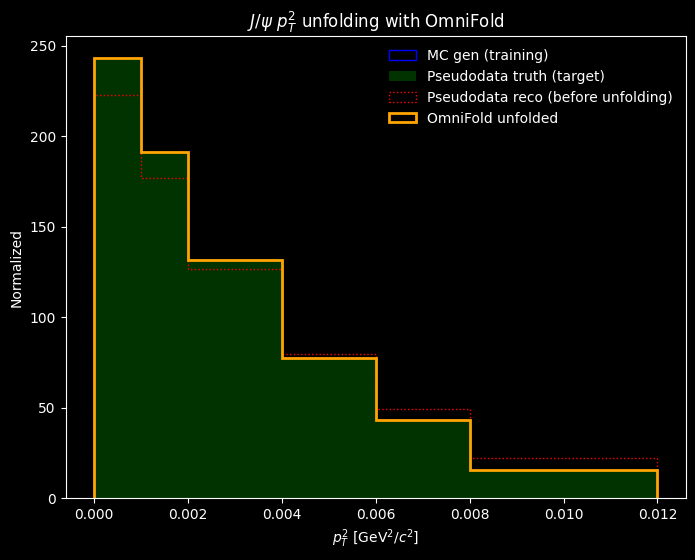

In [16]:
# =============================================================================
# Closure test: unfolded spectrum vs pseudodata truth.
#
#   MC gen (training)  : the prior OmniFold starts from
#   Pseudodata truth   : the target gen-level spectrum (held back until now)
#   Pseudodata reco    : the smeared detector-level input to OmniFold
#   OmniFold unfolded  : MC gen reweighted by the final push weights
#
# Good closure = unfolded matches pseudodata truth.
# =============================================================================
plt.figure(figsize=(8, 6))
plt.hist(mc_pt2_gen,   bins=BINS, density=True, histtype="step",
         color="blue",   label="MC gen (training)")
plt.hist(test_pt2_gen, bins=BINS, density=True, histtype="bar",
         color="green",  alpha=0.4, label="Pseudodata truth (target)")
plt.hist(test_pt2_reco, bins=BINS, density=True, histtype="step",
         color="red",    ls=":", label="Pseudodata reco (before unfolding)")
plt.hist(mc_pt2_gen,   bins=BINS, density=True, histtype="step",
         color="orange",  lw=2, weights=w_unfolded, label="OmniFold unfolded")
plt.xlabel(r"$p_T^2$ [GeV$^2/c^2$]")
plt.ylabel("Normalized")
plt.title(r"$J/\psi$ $p_T^2$ unfolding with OmniFold")
plt.legend(frameon=False)
plt.show()